<a href="https://colab.research.google.com/github/MInesGomes/DataScienceObesityLevels/blob/main/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
airbnb = pd.read_csv(r'/content/airbnb.csv')
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18723 entries, 0 to 18722
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   room_id               18723 non-null  int64  
 1   survey_id             18723 non-null  int64  
 2   host_id               18723 non-null  int64  
 3   room_type             18723 non-null  object 
 4   country               0 non-null      float64
 5   city                  18723 non-null  object 
 6   borough               0 non-null      float64
 7   neighborhood          18723 non-null  object 
 8   reviews               18723 non-null  int64  
 9   overall_satisfaction  18723 non-null  float64
 10  accommodates          18723 non-null  int64  
 11  bedrooms              18723 non-null  float64
 12  bathrooms             0 non-null      float64
 13  price                 18723 non-null  float64
 14  minstay               0 non-null      float64
 15  name               

In [7]:
display(airbnb)

,room_id,survey_id,host_id,room_type,country,city,borough,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,bathrooms,price,minstay,name,last_modified,latitude,longitude,location
0,10176931,1476,49180562,Shared room,NaN,Amsterdam,NaN,De Pijp / Rivierenbuurt,7,4.5,2,1.0,NaN,156.0,NaN,Red Light/ Canal view apartment (Shared),2017-07-23 13:06:27.391699,52.356209,4.887491,0101000020E610000033FAD170CA8C13403BC5AA41982D...
1,8935871,1476,46718394,Shared room,NaN,Amsterdam,NaN,Centrum West,45,4.5,4,1.0,NaN,126.0,NaN,Sunny and Cozy Living room in quite neighbours,2017-07-23 13:06:23.607187,52.378518,4.896120,0101000020E6100000842A357BA095134042791F477330...
2,14011697,1476,10346595,Shared room,NaN,Amsterdam,NaN,Watergraafsmeer,1,0.0,3,1.0,NaN,132.0,NaN,Amsterdam,2017-07-23 13:06:23.603546,52.338811,4.943592,0101000020E6100000A51133FB3CC613403543AA285E2B...
3,6137978,1476,8685430,Shared room,NaN,Amsterdam,NaN,Centrum West,7,5.0,4,1.0,NaN,121.0,NaN,Canal boat RIDE in Amsterdam,2017-07-23 13:06:22.689787,52.376319,4.890028,0101000020E6100000DF180280638F134085EE92382B30...
4,18630616,1476,70191803,Shared room,NaN,Amsterdam,NaN,De Baarsjes / Oud West,1,0.0,2,1.0,NaN,93.0,NaN,One room for rent in a three room appartment,2017-07-23 13:06:19.681469,52.370384,4.852873,0101000020E6100000CD902A8A57691340187B2FBE682F...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18718,17789893,1476,47501089,Private room,NaN,Amsterdam,NaN,Bijlmer Centrum,10,5.0,3,1.0,NaN,32.0,NaN,"1-3 pers. Cozy Rm AFAS Live, ArenA, ZIGGODOME",2017-07-22 16:05:14.158963,52.319794,4.955638,0101000020E6100000684293C492D2134080BA8102EF28...
18719,16877166,1476,67093870,Private room,NaN,Amsterdam,NaN,Bijlmer Centrum,6,5.0,4,1.0,NaN,24.0,NaN,"Modern Room by Arena, ZIGGO, HmH",2017-07-22 16:05:14.151986,52.319080,4.954822,0101000020E61000005801BEDBBCD1134062670A9DD728...
18720,19859427,1476,29724632,Private room,NaN,Amsterdam,NaN,Geuzenveld / Slotermeer,0,0.0,1,1.0,NaN,38.0,NaN,Private single room,2017-07-22 16:05:14.149610,52.384028,4.838403,0101000020E61000002079E750865A1340C85F5AD42731...
18721,17132164,1476,115156569,Private room,NaN,Amsterdam,NaN,Centrum West,13,4.5,2,1.0,NaN,36.0,NaN,City Center studio in Touristic Amsterdam 1,2017-07-22 16:05:14.146183,52.372120,4.890982,0101000020E6100000774CDD955D9013400118CFA0A12F...


In [4]:
correlation = airbnb['reviews'].corr(airbnb['overall_satisfaction'], method='pearson')
print(f"Pearson correlation between reviews and overall_satisfaction: {correlation:.2f}")

Pearson correlation between reviews and overall_satisfaction: 0.32


The Pearson correlation between reviews and overall_satisfaction is 0.32. This indicates a weak positive linear relationship between the number of reviews and the overall satisfaction.

A Pearson correlation of 0.32 indicates a weak positive linear relationship. Generally, the strength of a linear relationship based on the absolute value of the Pearson correlation coefficient is interpreted as follows:

0.0 to 0.2: Very weak to negligible correlation
0.2 to 0.4: Weak correlation
0.4 to 0.6: Moderate correlation
0.6 to 0.8: Strong correlation
0.8 to 1.0: Very strong correlation

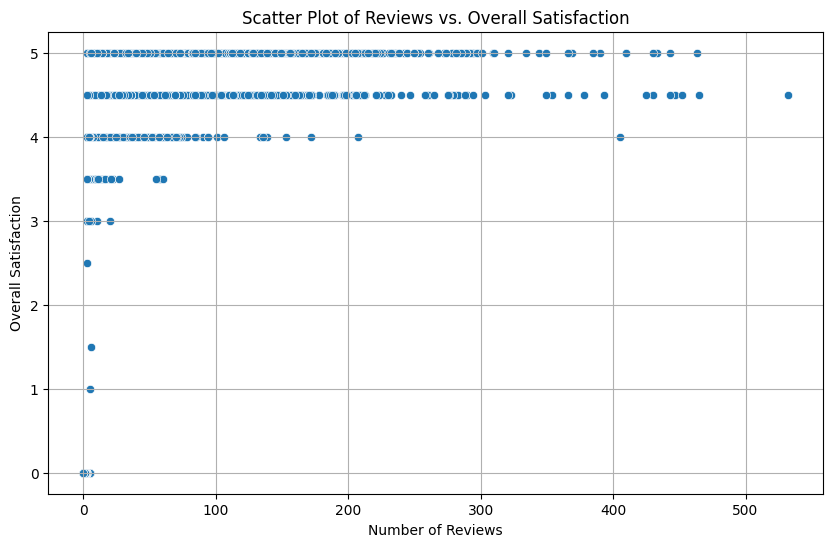

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='reviews', y='overall_satisfaction', data=airbnb)
plt.title('Scatter Plot of Reviews vs. Overall Satisfaction')
plt.xlabel('Number of Reviews')
plt.ylabel('Overall Satisfaction')
plt.grid(True)
plt.show()

In [6]:
numerical_cols = airbnb.select_dtypes(include=['number']).columns
correlations = {}

for col in numerical_cols:
    if col != 'price': # Exclude price correlating with itself
        correlation = airbnb[col].corr(airbnb['price'], method='pearson')
        correlations[col] = correlation

# Find the variable with the highest absolute correlation
highest_corr_var = max(correlations, key=lambda x: abs(correlations[x]))
highest_corr_value = correlations[highest_corr_var]

print(f"The variable with the highest Pearson correlation with 'price' is '{highest_corr_var}' with a correlation of {highest_corr_value:.2f}.")

The variable with the highest Pearson correlation with 'price' is 'accommodates' with a correlation of 0.50.


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [10]:
num_houses_accommodates_one = len(airbnb[airbnb['accommodates'] == 1])
print(f"Total number of houses where 'accommodates' is 1: {num_houses_accommodates_one}")

Total number of houses where 'accommodates' is 1: 367


In [11]:
max_bedrooms = airbnb['bedrooms'].max()
print(f"The maximum number of bedrooms available is: {max_bedrooms}")

The maximum number of bedrooms available is: 10.0


In [14]:
overall_satisfaction = airbnb['overall_satisfaction'].mean()
print(f"Mean of overall satisfaction {overall_satisfaction:.1f}")

Mean of overall satisfaction 3.3


In [15]:
print(airbnb.isnull().sum())

room_id                     0
survey_id                   0
host_id                     0
room_type                   0
country                 18723
city                        0
borough                 18723
neighborhood                0
reviews                     0
overall_satisfaction        0
accommodates                0
bedrooms                    0
bathrooms               18723
price                       0
minstay                 18723
name                       52
last_modified               0
latitude                    0
longitude                   0
location                    0
dtype: int64


In [17]:
num_houses_accommodates_more15 = len(airbnb[airbnb['accommodates'] > 15])
print(f"Total number of houses that can accommodates more than 15 people: {num_houses_accommodates_more15}")

Total number of houses that can accommodates more than 15 people: 21


In [19]:
tot_reviews = airbnb['reviews'].sum()
print(f"Total number of reviews: {tot_reviews}")

Total number of reviews: 313452


In [21]:
num_observations = len(airbnb)
print(f"The airbnb dataset has {num_observations} observations.")

The airbnb dataset has 18723 observations.


To find out what value half of the houses are lower than, we calculate the median of the price column. This will give us the point where 50% of the prices are below that value.

In [28]:
median_price = airbnb['price'].median()
print(f"Half of the houses have a price lower than: {median_price:.2f}")

Half of the houses have a price lower than: 144.00


In [27]:
mean_price_of16 = (airbnb[airbnb['accommodates'] == 16]['price'].mean())
print(f"Mean price of a house that hosts 16 people: {mean_price_of16:.2f}")

Mean price of a house that hosts 16 people: 745.70


In [31]:
mean_price_overall_satisfaction_5 = airbnb[airbnb['overall_satisfaction'] == 5.0]['price'].mean()
print(f"Mean price of a house with overall satisfaction of 5: {mean_price_overall_satisfaction_5:.1f}")

Mean price of a house with overall satisfaction of 5: 170.23


In [32]:
# The most frequent type in 'room_type' is... mode
mode_room_type = airbnb['room_type'].mode()
print(f"Mode of room_type is: {mode_room_type}")

Mode of room_type is: 0    Entire home/apt
Name: room_type, dtype: object


In [33]:
# The most frequent neighborhood is...
mode_neighborhood = airbnb['neighborhood'].mode()
print(f"Mode of neighborhood is: {mode_neighborhood}")

Mode of neighborhood is: 0    De Baarsjes / Oud West
Name: neighborhood, dtype: object
